# AI Deep Learning - Homework 04

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1_Basic concepts and operations on tensors

### 1.1 Managing the dimensions and deformation of tensors

In [ ]:
images = torch.rand(32, 3, 64, 64)
print("Original images tensor shape:", images.shape)

Original images tensor shape: torch.Size([32, 3, 64, 64])


In [ ]:
flattened_images = images.view(images.size(0), -1)
print("Flattened images tensor shape:", flattened_images.shape)
assert flattened_images.shape == (32, 12288), "Flattened shape mismatch!"

Flattened images tensor shape: torch.Size([32, 12288])


Image shape ready for Matplotlib display: torch.Size([64, 64, 3])


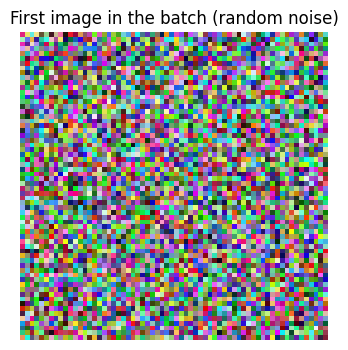

In [ ]:
# shape: (3, 64, 64)
first_image = images[0]
# shape: (64, 64, 3)
first_image_for_plot = first_image.permute(1, 2, 0)
print("Image shape ready for Matplotlib display:", first_image_for_plot.shape)
assert first_image_for_plot.shape == (64, 64, 3), "Permute shape mismatch!"

plt.figure(figsize=(4, 4))
plt.imshow(first_image_for_plot.numpy())
plt.title("First image in the batch (random noise)")
plt.axis("off")
plt.savefig("random_image_sample.png", dpi=120, bbox_inches="tight")
plt.show()

## 1.2 Automatic gradient calculation

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
print("x =", x.item())
y = x**3 + 5 * x**2 + 2
print("y =", y.item())

x = 2.0
y = 30.0


In [ ]:
# dy/dx = 3x^2 + 10x
# At x = 2: dy/dx = 3(4) + 10(2) = 12 + 20 = 32
x_val = 2.0
manual_derivative = 3 * (x_val ** 2) + 10 * x_val
print(f"Manual (analytical) derivative at x=2: {manual_derivative}")

Manual (analytical) derivative at x=2: 32.0


In [ ]:
y.backward()
autograd_derivative = x.grad.item()
print(f"Autograd derivative (x.grad) at x=2: {autograd_derivative}")
print(f"Manual result:   {manual_derivative}")
print(f"Autograd result: {autograd_derivative}")
print(f"Match: {np.isclose(manual_derivative, autograd_derivative)}")

Autograd derivative (x.grad) at x=2: 32.0
Manual result:   32.0
Autograd result: 32.0
Match: True


## 1.3 CPU and GPU performance comparison

In [ ]:
cuda_available = torch.cuda.is_available()
print(f"CUDA (GPU) available: {cuda_available}")
if cuda_available:
    print("GPU device name:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if cuda_available else "cpu")

CUDA (GPU) available: True
GPU device name: Tesla T4


In [ ]:
matrix_size = 1000
mat_a_cpu = torch.rand(matrix_size, matrix_size)
mat_b_cpu = torch.rand(matrix_size, matrix_size)

start_cpu = time.time()
result_cpu = torch.matmul(mat_a_cpu, mat_b_cpu)
end_cpu = time.time()
cpu_time = end_cpu - start_cpu
print(f"CPU matrix multiplication time: {cpu_time:.6f} seconds")

CPU matrix multiplication time: 0.050744 seconds


In [ ]:
if cuda_available:
    mat_a_gpu = mat_a_cpu.to(device)
    mat_b_gpu = mat_b_cpu.to(device)

    # Warm-up run to avoid measuring CUDA context initialization overhead
    _ = torch.matmul(mat_a_gpu, mat_b_gpu)
    torch.cuda.synchronize()

    start_gpu = time.time()
    result_gpu = torch.matmul(mat_a_gpu, mat_b_gpu)
    torch.cuda.synchronize()  # wait for GPU to finish before stopping the timer
    end_gpu = time.time()
    gpu_time = end_gpu - start_gpu

    print(f"GPU matrix multiplication time: {gpu_time:.6f} seconds")
    print(f"Speed-up factor (CPU time / GPU time): {cpu_time / gpu_time:.2f}x")
else:
    print("No GPU detected in this environment.")

GPU matrix multiplication time: 0.000888 seconds
Speed-up factor (CPU time / GPU time): 57.12x


# 2_Regression problem (predicting medical costs)

### 2.1 Data preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/deep/insurance_Deep.xlsx"

In [ ]:
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
pd.options.display.float_format = '{:.3f}'.format

df = pd.read_excel(file_path)

print("Dataset Preview:")
display(df.head(10))

print("\nDataset Information:")

info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Non-Null Count": df.count(),
    "Unique Values": df.nunique()
})

display(info_df)
print("\nDescriptive Statistics:")
display(df.describe(include='all').T)

Dataset Preview:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855
5,31,female,25.740,0,no,southeast,3756.622
6,46,female,33.440,1,no,southeast,8240.590
7,37,female,27.740,3,no,northwest,7281.506
8,37,male,29.830,2,no,northeast,6406.411
9,60,female,25.840,0,no,northwest,28923.137



Dataset Information:


,Data Type,Missing Values,Non-Null Count,Unique Values
age,int64,0,1338,47
sex,object,0,1338,2
bmi,float64,0,1338,548
children,int64,0,1338,6
smoker,object,0,1338,2
region,object,0,1338,4
charges,float64,0,1338,1337



Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.000,NaN,NaN,NaN,39.207,14.050,18.000,27.000,39.000,51.000,64.000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.000,NaN,NaN,NaN,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,NaN,NaN,NaN,1.095,1.205,0.000,0.000,1.000,2.000,5.000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.000,NaN,NaN,NaN,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428


### Preprocessing - One-Hot Encoding for categorical variables

In [ ]:
categorical_cols = ["sex", "smoker", "region"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print("Columns after one-hot encoding:", df_encoded.columns.tolist())
df_encoded.head()

Columns after one-hot encoding: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.924,0,1,0,0,1
1,18,33.770,1,1725.552,1,0,0,1,0
2,28,33.000,3,4449.462,1,0,0,1,0
3,33,22.705,0,21984.471,1,0,1,0,0
4,32,28.880,0,3866.855,1,0,1,0,0


### Separating features (X) and target (y)

In [ ]:
X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

print(f"Number of input features: {X.shape[1]}")
print(f"Features: {X.columns.tolist()}")

Number of input features: 8
Features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


### Splitting data into training and testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training data: {X_train.shape[0]} Sample")
print(f"Test data: {X_test.shape[0]} Sample")

Training data: 1070 Sample
Test data: 268 Sample


### Preprocessing - Standardize continuous variables (age, bmi)

In [ ]:
continuous_cols = ["age", "bmi", "children"]

scaler_X = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler_X.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler_X.transform(X_test[continuous_cols])

X_train_scaled.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,0.472,-1.757,0.734,0,0,1,0,0
1285,0.543,-1.033,-0.911,0,0,0,0,0
1142,0.899,-0.944,-0.911,0,0,0,1,0
969,-0.025,0.622,3.203,0,0,0,1,0
486,1.041,-1.505,1.557,0,0,1,0,0


### Convert final data to PyTorch tensors (FloatTensor)

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled.values,  dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1).to(device)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"dtype: {X_train_tensor.dtype}")


X_train_tensor shape: torch.Size([1070, 8])
y_train_tensor shape: torch.Size([1070, 1])
dtype: torch.float32


### 2.2 Base model

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"Linear Regression - Test MSE: {mse_linear:.4f}")
print(f"Linear Regression - Test RMSE: {np.sqrt(mse_linear):.4f}")

Linear Regression - Test MSE: 33596915.8514
Linear Regression - Test RMSE: 5796.2847


### 2.3 Neural network model

In [ ]:
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

print(model)


Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
EPOCHS = 100

train_losses = []
test_losses = []

for epoch in range(1, EPOCHS + 1):
   #Training mode
    model.train()
    optimizer.zero_grad()

    y_pred_train = model(X_train_tensor)
    loss = criterion(y_pred_train, y_train_tensor)

    loss.backward()
    optimizer.step()

   #Evaluation of test data at each epoch
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test_tensor)
        test_loss = criterion(y_pred_test, y_test_tensor)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{EPOCHS}] | Train Loss: {loss.item():,.2f} | Test Loss: {test_loss.item():,.2f}")


Epoch [  1/100] | Train Loss: 322,450,080.00 | Test Loss: 323,414,944.00
Epoch [ 10/100] | Train Loss: 322,232,736.00 | Test Loss: 323,152,512.00
Epoch [ 20/100] | Train Loss: 321,016,960.00 | Test Loss: 321,770,048.00
Epoch [ 30/100] | Train Loss: 317,081,440.00 | Test Loss: 317,436,416.00
Epoch [ 40/100] | Train Loss: 307,552,864.00 | Test Loss: 307,157,376.00
Epoch [ 50/100] | Train Loss: 288,705,760.00 | Test Loss: 287,144,128.00
Epoch [ 60/100] | Train Loss: 257,267,264.00 | Test Loss: 254,246,992.00
Epoch [ 70/100] | Train Loss: 213,135,104.00 | Test Loss: 208,866,688.00
Epoch [ 80/100] | Train Loss: 163,079,264.00 | Test Loss: 158,740,432.00
Epoch [ 90/100] | Train Loss: 122,379,528.00 | Test Loss: 119,928,512.00
Epoch [100/100] | Train Loss: 104,116,832.00 | Test Loss: 103,943,688.00


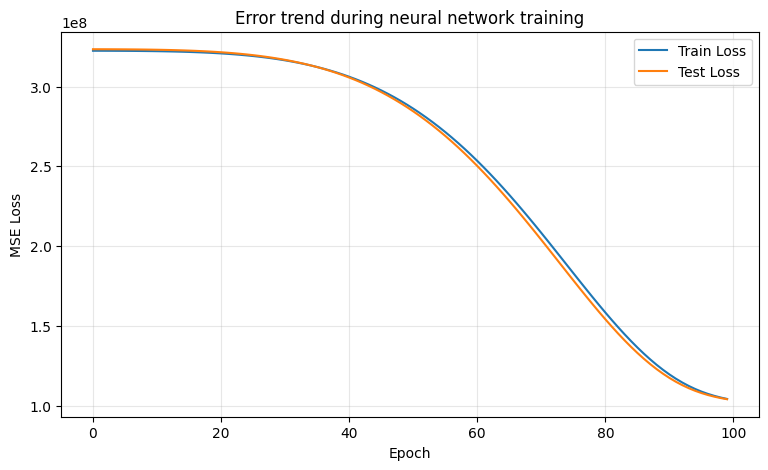

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Error trend during neural network training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.4 Analysis of results

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_tensor)
    mse_nn = criterion(y_pred_nn, y_test_tensor).item()

rmse_nn = np.sqrt(mse_nn)

print(f"Neural Network - Test MSE: {mse_nn:.4f}")
print(f"Neural Network - Test RMSE: {np.sqrt(mse_nn):.4f}")

Neural Network - Test MSE: 103943688.0000
Neural Network - Test RMSE: 10195.2777


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "Test MSE": [mse_linear, mse_nn],
    "Test RMSE": [np.sqrt(mse_linear), np.sqrt(mse_nn)]
})
print(comparison_df)
comparison_df.to_csv("model_comparison_results.csv", index=False)
improvement = (mse_linear - mse_nn) / mse_linear * 100
print(f"\nError Improvement over Linear Regression: {improvement:.2f}%")

               Model      Test MSE  Test RMSE
0  Linear Regression  33596915.851   5796.285
1     Neural Network 103943688.000  10195.278

Error Improvement over Linear Regression: -209.38%


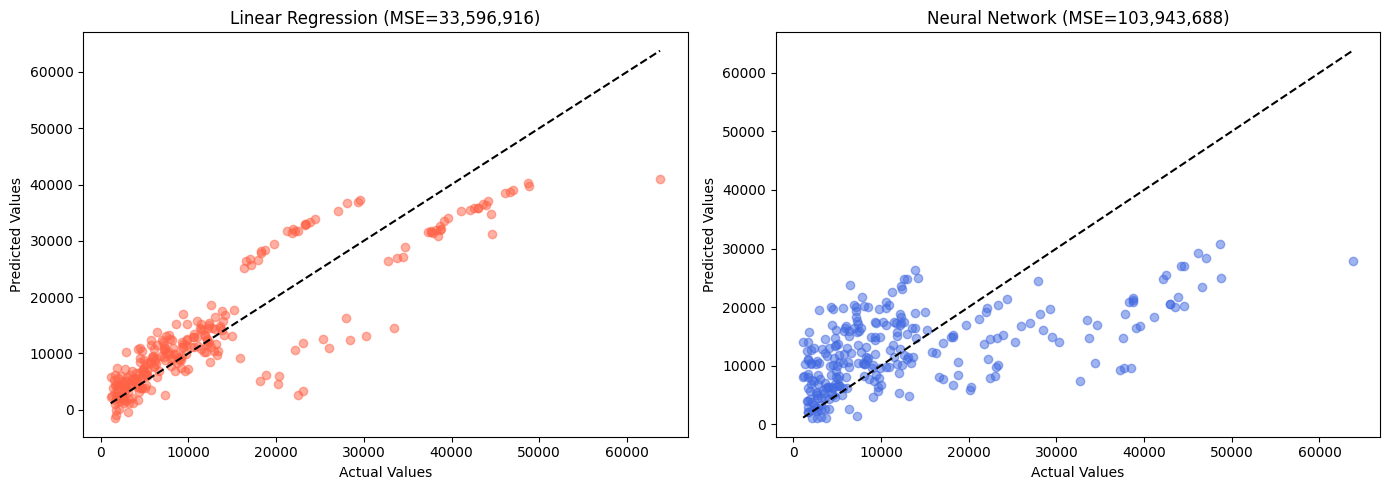

In [ ]:
y_pred_nn_np = y_pred_nn.cpu().numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_linear, alpha=0.5, color="tomato")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0].set_title(f"Linear Regression (MSE={mse_linear:,.0f})")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")

axes[1].scatter(y_test, y_pred_nn_np, alpha=0.5, color="royalblue")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[1].set_title(f"Neural Network (MSE={mse_nn:,.0f})")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")

plt.tight_layout()
plt.show()


## Why does ReLU help in learning nonlinear relationships?

>The ReLU activation function introduces nonlinearity into the neural network, allowing the model to learn complex relationships and interactions between features. Without ReLU, even a multilayer network would be mathematically equivalent to a linear model and would not be able to learn nonlinear patterns. ReLU also makes model training faster and more stable by reducing the Vanishing Gradient problem, and as a result, usually results in lower prediction error than linear models.



# 3_ Image classification problem (dataset) CIFAR-10

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

### 3.1 Data preparation

### 3.2  Network architecture design
>Input: 3×32×32 = 3072 → First layer: 512 (ReLU) → Second layer: 256 (ReLU) → Third layer: 128 (ReLU) → Output: 10 classes

In [ ]:
class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [ ]:
def train_model(optimizer_name, epochs=10):
    model = FCNet().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        raise ValueError("Optimizer not supported")

    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataset)
        loss_history.append(epoch_loss)
        print(f"[{optimizer_name}] Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

    return model, loss_history

### Model evaluation function

In [ ]:
def evaluate_model(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

### Comparison of optimizer performance


In [ ]:
EPOCHS = 10
model_sgd, loss_sgd = train_model("SGD", epochs=EPOCHS)
acc_sgd = evaluate_model(model_sgd)

[SGD] Epoch 1/10 - Loss: 1.8995
[SGD] Epoch 2/10 - Loss: 1.5436
[SGD] Epoch 3/10 - Loss: 1.4034
[SGD] Epoch 4/10 - Loss: 1.3086
[SGD] Epoch 5/10 - Loss: 1.2264
[SGD] Epoch 6/10 - Loss: 1.1568
[SGD] Epoch 7/10 - Loss: 1.0925
[SGD] Epoch 8/10 - Loss: 1.0330
[SGD] Epoch 9/10 - Loss: 0.9663
[SGD] Epoch 10/10 - Loss: 0.9069
Test Accuracy: 55.55%


In [ ]:
model_adam, loss_adam = train_model("Adam", epochs=EPOCHS)
acc_adam = evaluate_model(model_adam)

[Adam] Epoch 1/10 - Loss: 1.6499
[Adam] Epoch 2/10 - Loss: 1.4274
[Adam] Epoch 3/10 - Loss: 1.3106
[Adam] Epoch 4/10 - Loss: 1.2120
[Adam] Epoch 5/10 - Loss: 1.1255
[Adam] Epoch 6/10 - Loss: 1.0426
[Adam] Epoch 7/10 - Loss: 0.9676
[Adam] Epoch 8/10 - Loss: 0.8822
[Adam] Epoch 9/10 - Loss: 0.8074
[Adam] Epoch 10/10 - Loss: 0.7407
Test Accuracy: 53.47%


### Comparison of Loss Graphs between Two Optimizers

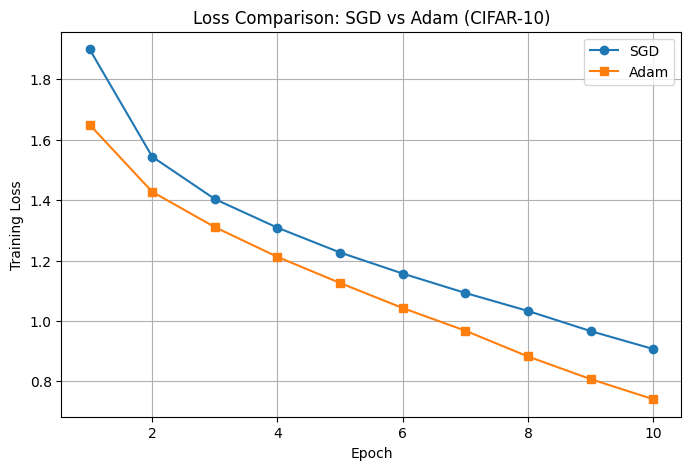

Final Accuracy -> SGD: 55.55%  |  Adam: 53.47%


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), loss_sgd, marker='o', label='SGD')
plt.plot(range(1, EPOCHS + 1), loss_adam, marker='s', label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss Comparison: SGD vs Adam (CIFAR-10)')
plt.legend()
plt.grid(True)
plt.savefig('loss_comparison.png', dpi=150)
plt.show()

print(f"Final Accuracy -> SGD: {acc_sgd:.2f}%  |  Adam: {acc_adam:.2f}%")

## 3.4 Model evaluation

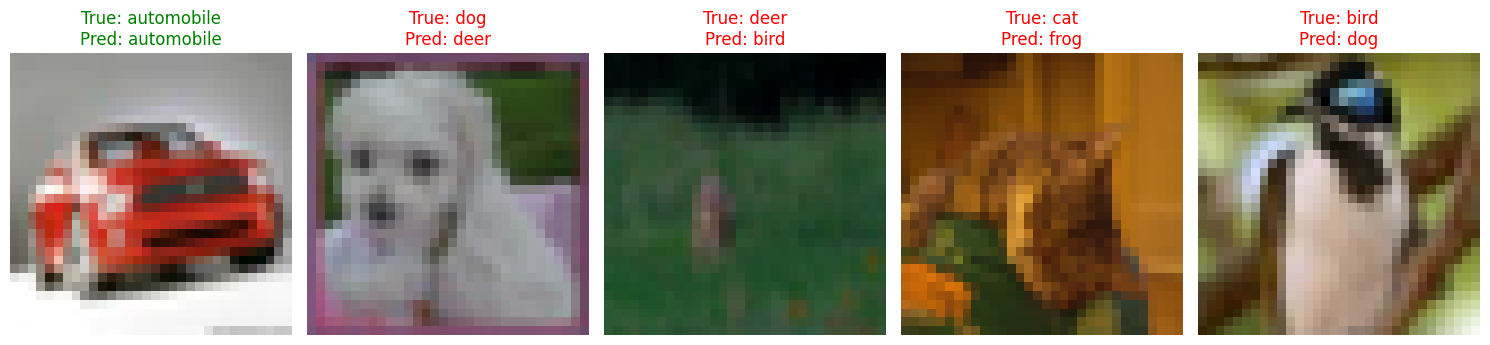

In [ ]:
model_adam.eval()
indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, idx in enumerate(indices):
    image, true_label = test_dataset[idx]
    img_input = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model_adam(img_input)
        _, pred = torch.max(output, 1)

    img_show = image.numpy().transpose((1, 2, 0))
    img_show = (img_show * 0.5) + 0.5  # denormalize

    axes[i].imshow(img_show)
    axes[i].set_title(
        f"True: {classes[true_label]}\nPred: {classes[pred.item()]}",
        color=("green" if pred.item() == true_label else "red")
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()